<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/sztuczna_lab_zad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)



2.19.0


In [42]:
observations = 100000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(100000, 2)


In [43]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)


(100000, 1)


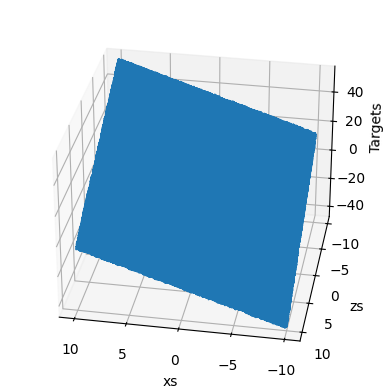

In [44]:

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [45]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[ 0.04943851]
 [-0.05433775]] [0.04158054]


In [46]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


220.137528752235
35.188073117453136
14.114180819391128
11.36234325255504
10.673249070273474
10.229762302081784
9.828236575798067
9.445337715239848
9.077905582322698
8.72505689330702
8.386183896687434
8.060729804715782
7.748162885226727
7.447972797745949
7.159669447584613
6.882782150725279
6.616858861469228
6.361465433989444
6.116184913495977
5.880616855510889
5.65437667210282
5.437095004009448
5.2284171176222936
5.028002325849354
4.83552343191005
4.650666195154436
4.473128818034542
4.302621453390337
4.138865731245811
3.9815943043427526
3.8305504116701345
3.6854874592766254
3.546168617681814
3.4123664352288534
3.2838624667473817
3.160446916920363
3.0419182977726904
2.928083099722316
2.8187554756569133
2.713756937520259
2.6129160649129934
2.516068225232022
2.4230553048916725
2.3337254511877696
2.247932824383223
2.165537359610363
2.0864045382013416
2.0104051680732042
1.937415172809181
1.8673153890917624
1.799991372156926
1.7353332089518398
1.6732353386910377
1.6135963805180915
1.556318967

In [47]:
print(weights, biases)

[[ 2.00093719]
 [-2.99979235]] [4.34471369]


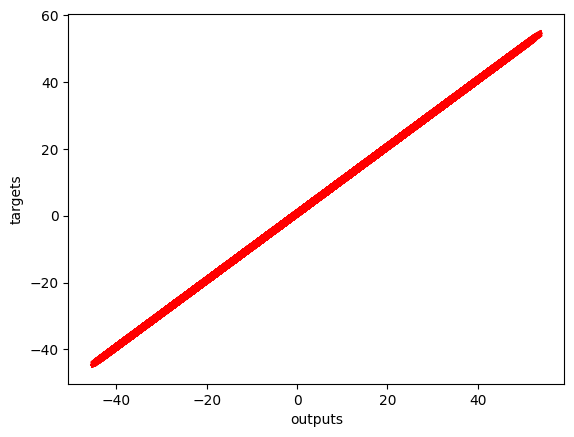

In [48]:
plt.plot(outputs, targets, color='red')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()